In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('/home/claudiagalantino/eda-architecture/services/data_analysis/fusion_df.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12863 entries, 0 to 12862
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp_local      12863 non-null  object 
 1   garmin_id            12863 non-null  object 
 2   room                 12863 non-null  object 
 3   stress_score         6281 non-null   float64
 4   body_battery         6281 non-null   float64
 5   hr                   10782 non-null  float64
 6   activity_type        1589 non-null   object 
 7   intensity            1589 non-null   object 
 8   steps                1589 non-null   float64
 9   respiration_rate     1787 non-null   float64
 10  temperature_DHT22_C  12863 non-null  float64
 11  humidity_DHT22_%     12863 non-null  float64
 12  CO2_ppm              12863 non-null  float64
 13  TVOC_ppb             12863 non-null  float64
dtypes: float64(9), object(5)
memory usage: 1.4+ MB


In [6]:
df["activity_type"].unique()

array([nan, 'SEDENTARY'], dtype=object)

In [7]:
df["garmin_id"].unique()

array(['66c2c60b-769f-4d63-b470-a3ae5c6ed251',
       '8d738deb-db44-405e-ac6a-ce73135eb434'], dtype=object)

In [8]:
df["room"].unique()

array(['home', 'library', 'lab'], dtype=object)

In [9]:
df["intensity"].unique()

array([nan, 'SEDENTARY'], dtype=object)

In [10]:
df["steps"].unique()

array([nan,  0.])

In [11]:
df.isna().sum()

timestamp_local            0
garmin_id                  0
room                       0
stress_score            6582
body_battery            6582
hr                      2081
activity_type          11274
intensity              11274
steps                  11274
respiration_rate       11076
temperature_DHT22_C        0
humidity_DHT22_%           0
CO2_ppm                    0
TVOC_ppb                   0
dtype: int64

In [12]:
df["stress_score"] = df["stress_score"].bfill()

In [13]:
df["body_battery"] = df["body_battery"].bfill()

In [14]:
df["hr"] = df["hr"].bfill()

In [15]:
df["respiration_rate"] = df["respiration_rate"].bfill()


In [16]:
df.isna().sum()

timestamp_local            0
garmin_id                  0
room                       0
stress_score               3
body_battery               3
hr                         0
activity_type          11274
intensity              11274
steps                  11274
respiration_rate           3
temperature_DHT22_C        0
humidity_DHT22_%           0
CO2_ppm                    0
TVOC_ppb                   0
dtype: int64

In [17]:
df

,timestamp_local,garmin_id,room,stress_score,body_battery,hr,activity_type,intensity,steps,respiration_rate,temperature_DHT22_C,humidity_DHT22_%,CO2_ppm,TVOC_ppb
0,2026-01-11 09:00:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,home,20.0,35.0,68.0,NaN,NaN,NaN,14.72,19.4,52.6,402.0,0.0
1,2026-01-11 09:00:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,home,20.0,35.0,68.0,NaN,NaN,NaN,14.72,19.4,52.6,402.0,0.0
2,2026-01-11 09:00:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,home,20.0,35.0,68.0,NaN,NaN,NaN,14.72,19.4,52.6,402.0,0.0
3,2026-01-11 09:00:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,home,20.0,35.0,68.0,NaN,NaN,NaN,14.72,19.4,52.6,402.0,0.0
4,2026-01-11 09:00:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,home,20.0,35.0,68.0,NaN,NaN,NaN,14.72,19.4,52.6,402.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2026-01-27 10:29:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,library,72.0,39.0,90.0,SEDENTARY,SEDENTARY,0.0,17.83,16.9,67.4,400.0,2.0
12859,2026-01-27 10:29:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,library,72.0,39.0,90.0,SEDENTARY,SEDENTARY,0.0,17.83,16.9,67.4,400.0,2.0
12860,2026-01-27 10:29:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,library,NaN,NaN,90.0,SEDENTARY,SEDENTARY,0.0,NaN,16.9,67.4,400.0,2.0
12861,2026-01-27 10:30:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,library,NaN,NaN,94.0,SEDENTARY,SEDENTARY,0.0,NaN,16.9,67.4,400.0,2.0


Creiamo training dataframe
Definiamo TARGET, TRAIN_FEATURES 

In [216]:
TARGET = "stress_score"
FEATURES = ["body_battery", "hr", "respiration_rate", "temperature_DHT22_C", "humidity_DHT22_%", "CO2_ppm", "TVOC_ppb"]
# FEATURES = ["hr", "respiration_rate", "temperature_DHT22_C", "humidity_DHT22_%", "CO2_ppm", "TVOC_ppb"]
# FEATURES = ["respiration_rate", "temperature_DHT22_C", "humidity_DHT22_%", "CO2_ppm", "TVOC_ppb"]



In [217]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

In [ ]:
# remove NaN values 

X.fillna(X.mean(), inplace = True)

In [219]:
y.fillna(y.mean(), inplace = True)

In [220]:
X

,body_battery,hr,respiration_rate,temperature_DHT22_C,humidity_DHT22_%,CO2_ppm,TVOC_ppb
0,35.00,68.00,14.72,19.40,52.60,402.00,0.00
1,35.00,68.00,14.72,19.40,52.60,402.00,0.00
2,35.00,68.00,14.72,19.40,52.60,402.00,0.00
3,35.00,68.00,14.72,19.40,52.60,402.00,0.00
4,35.00,68.00,14.72,19.40,52.60,402.00,0.00
...,...,...,...,...,...,...,...
12858,39.00,90.00,17.83,16.90,67.40,400.00,2.00
12859,39.00,90.00,17.83,16.90,67.40,400.00,2.00
12860,31.33,90.00,16.25,16.90,67.40,400.00,2.00
12861,31.33,94.00,16.25,16.90,67.40,400.00,2.00


In [221]:
print(X.isna().sum())

body_battery           0
hr                     0
respiration_rate       0
temperature_DHT22_C    0
humidity_DHT22_%       0
CO2_ppm                0
TVOC_ppb               0
dtype: int64


In [222]:
print(y.isna().sum())

0


Correlazione tra features

In [223]:
df_corr = df[FEATURES + [TARGET]].corr()

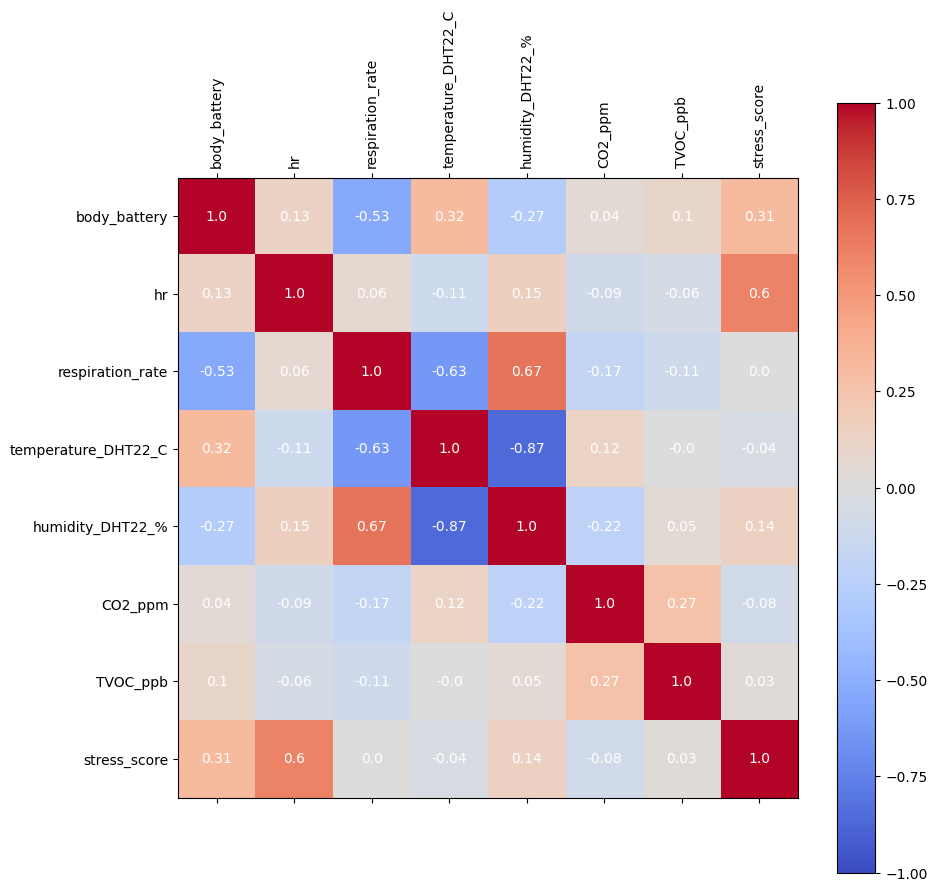

In [224]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))
cax     = ax.matshow(df_corr,cmap='coolwarm', vmin=-1, vmax=1)

fig.colorbar(cax)
ticks = np.arange(0,len(df_corr.columns),1)
ax.set_xticks(ticks)

ax.set_xticklabels(df_corr.columns)
plt.xticks(rotation = 90)

ax.set_yticklabels(df_corr.columns)
ax.set_yticks(ticks)

#---print the correlation factor---
for i in range(df_corr.shape[1]):
    for j in range(df_corr.shape[1]):
        text = ax.text(j, i, round(df_corr.iloc[i][j],2),
                       ha="center", va="center", color="w")
plt.show()

## REGRESSION

In [225]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [226]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [227]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(10290, 7) (2573, 7) (10290,) (2573,)


In [228]:
clf = LazyRegressor(predictions=True)

# fit the data using different algorithms
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
models

  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000465 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 10290, number of used features: 7
[LightGBM] [Info] Start training from score 45.894920


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreesRegressor,0.91,0.91,5.15,0.60
RandomForestRegressor,0.91,0.91,5.23,0.81
DecisionTreeRegressor,0.91,0.91,5.24,0.02
ExtraTreeRegressor,0.91,0.91,5.26,0.02
BaggingRegressor,0.91,0.91,5.27,0.09
XGBRegressor,0.89,0.89,5.78,0.29
KNeighborsRegressor,0.85,0.85,6.64,0.03
HistGradientBoostingRegressor,0.84,0.84,6.95,0.63
LGBMRegressor,0.83,0.84,6.96,0.49


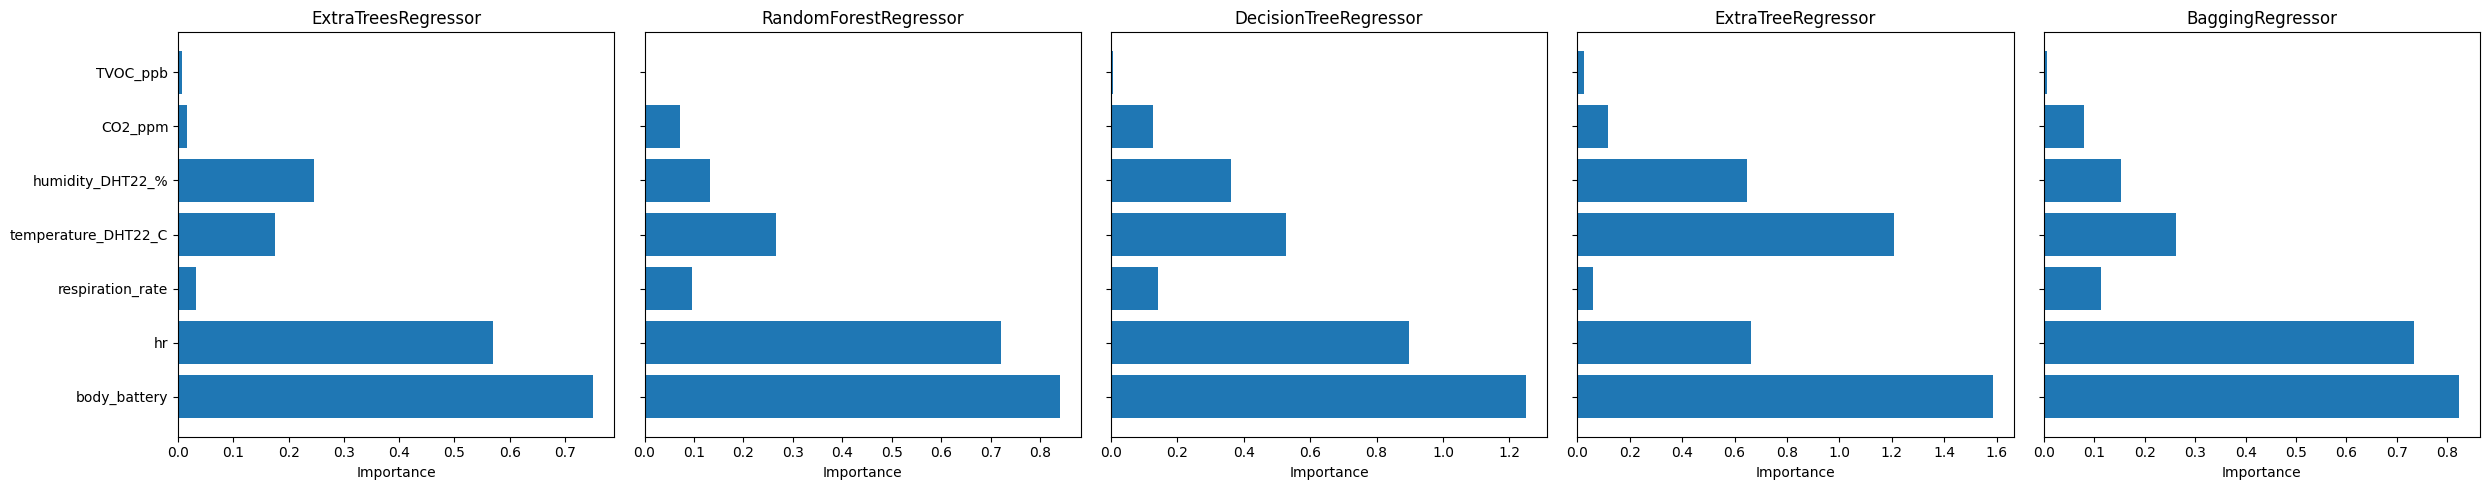

In [229]:
from sklearn.inspection import permutation_importance

N = 5  # Puoi cambiare questo valore come preferisci

# Prendi i primi N modelli dal ranking
top_N_models = models.head(N).index.tolist()

fig, axes = plt.subplots(1, N, figsize=(5*N, 5), sharey=True)

for idx, model_name in enumerate(top_N_models):
    # Ottieni il modello addestrato da LazyRegressor
    model = clf.models[model_name]
    # Calcola la feature importance
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = model.coef_[0]
    else:
        # fallback: permutation importance
        result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
        importances = result.importances_mean

    axes[idx].barh(FEATURES, importances)
    axes[idx].set_title(model_name)
    axes[idx].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [230]:
# 1. Residual plots for top N models
from sklearn.metrics import mean_absolute_error, mean_squared_error

N = 5
top_N_models = models.head(N).index.tolist()

fig, axes = plt.subplots(1, N, figsize=(5*N, 4))

for idx, model_name in enumerate(top_N_models):
    y_pred = predictions[model_name].values  # Convert to numpy array
    y_true = y_test.values  # Convert to numpy array
    residuals = y_true - y_pred
    
    axes[idx].scatter(y_pred, residuals, alpha=0.5)
    axes[idx].axhline(y=0, color='r', linestyle='--')
    axes[idx].set_xlabel('Predicted Values')
    axes[idx].set_ylabel('Residuals')
    axes[idx].set_title(f'{model_name}\nResiduals')
    
plt.tight_layout()
plt.show()

In [231]:
# 2. Actual vs Predicted scatter plots
fig, axes = plt.subplots(1, N, figsize=(5*N, 4))

for idx, model_name in enumerate(top_N_models):
    y_pred = predictions[model_name].values
    y_true = y_test.values
    
    axes[idx].scatter(y_true, y_pred, alpha=0.5)
    axes[idx].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[idx].set_xlabel('Actual')
    axes[idx].set_ylabel('Predicted')
    axes[idx].set_title(f'{model_name}')
    
plt.tight_layout()
plt.show()

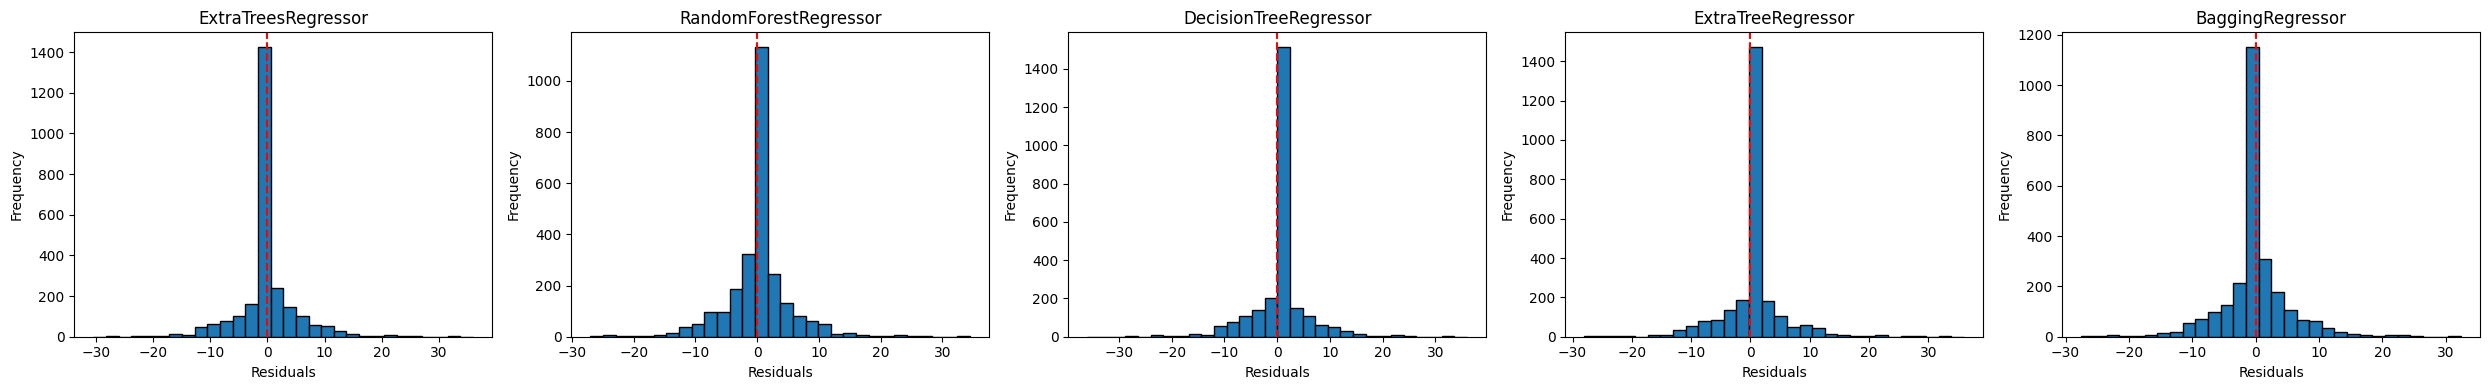

In [232]:
# 3. Distribution of residuals (to check normality)
fig, axes = plt.subplots(1, N, figsize=(5*N, 4))

for idx, model_name in enumerate(top_N_models):
    y_pred = predictions[model_name].values
    y_true = y_test.values
    residuals = y_true - y_pred
    
    axes[idx].hist(residuals, bins=30, edgecolor='black')
    axes[idx].set_xlabel('Residuals')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{model_name}')
    axes[idx].axvline(x=0, color='r', linestyle='--')
    
plt.tight_layout()
plt.show()

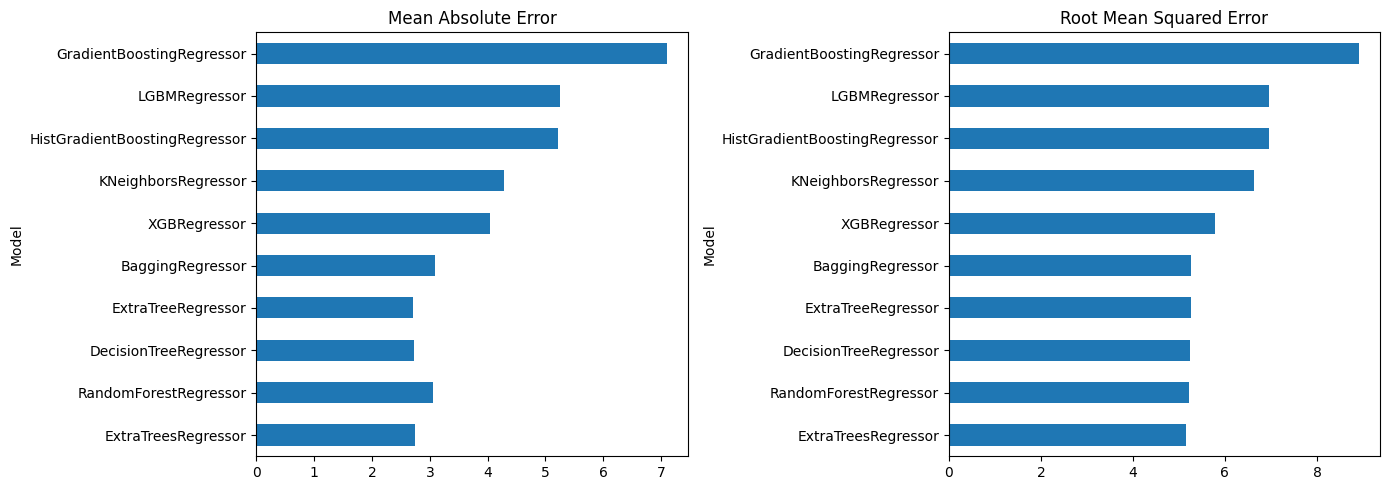

In [233]:
# 4. Error metrics comparison bar chart
metrics_data = []
for model_name in models.head(10).index:
    y_pred = predictions[model_name].values
    y_true = y_test.values
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    metrics_data.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse})

metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_df.plot(x='Model', y='MAE', kind='barh', ax=axes[0], legend=False)
axes[0].set_title('Mean Absolute Error')
metrics_df.plot(x='Model', y='RMSE', kind='barh', ax=axes[1], legend=False)
axes[1].set_title('Root Mean Squared Error')
plt.tight_layout()
plt.show()

Best models per family (Regression):
Tree-based: ExtraTreesRegressor (R² = 0.9098, RMSE = 5.1549)
SVM: NuSVR (R² = 0.5999, RMSE = 10.8585)
Linear: ElasticNetCV (R² = 0.4227, RMSE = 13.0431)
Ensemble: ExtraTreesRegressor (R² = 0.9098, RMSE = 5.1549)
Neighbors: KNeighborsRegressor (R² = 0.8505, RMSE = 6.6362)


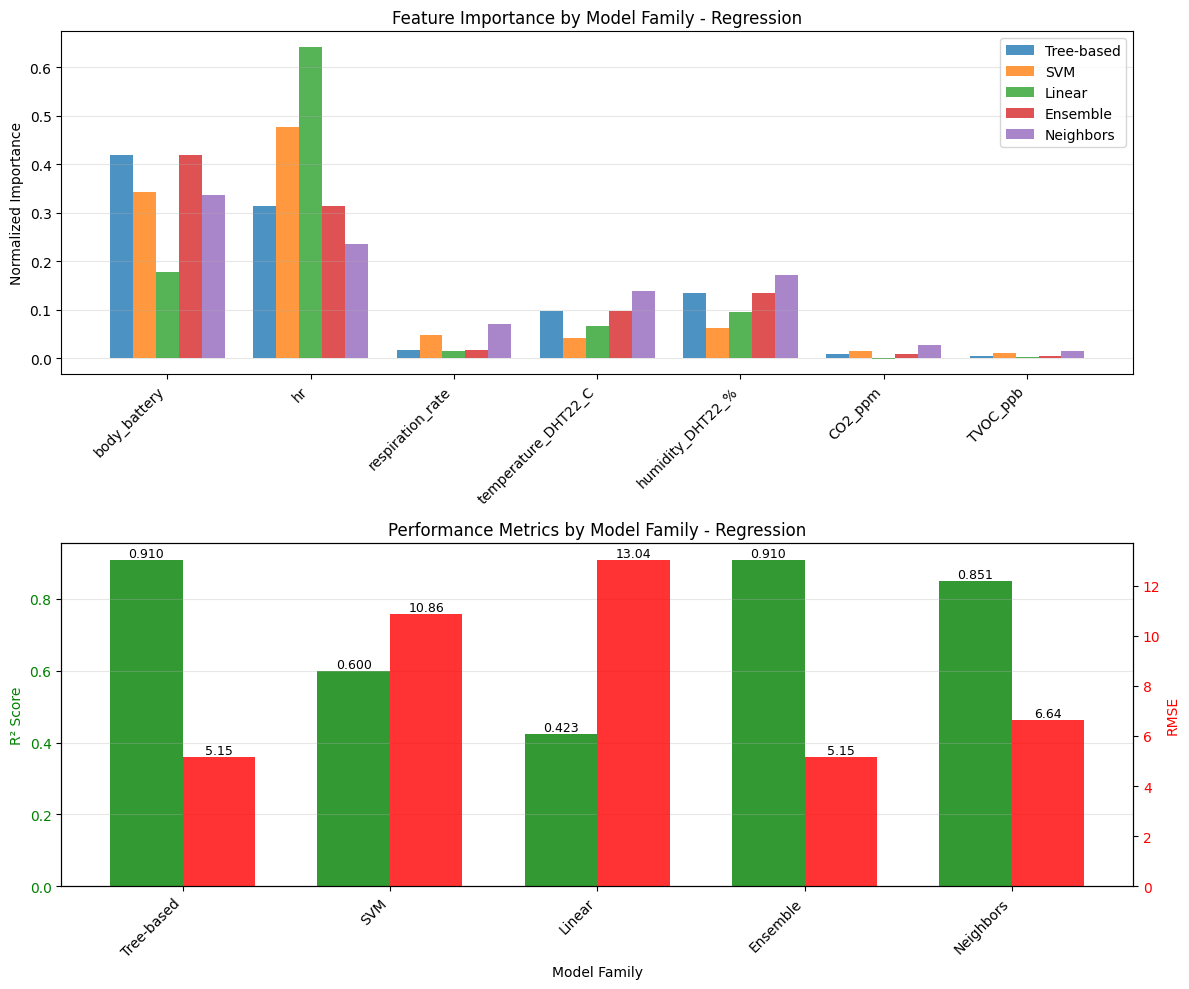

In [234]:
# 5. Feature Importance and Performance by Model Family - REGRESSION
from sklearn.inspection import permutation_importance

# Define model families based on common model types
model_families = {
    'Tree-based': ['ExtraTreesRegressor', 'RandomForestRegressor', 'GradientBoostingRegressor', 
                   'HistGradientBoostingRegressor', 'XGBRegressor', 'LGBMRegressor'],
    'SVM': ['SVR', 'NuSVR'],
    'Linear': ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'LassoLars', 
               'BayesianRidge', 'HuberRegressor', 'SGDRegressor'],
    'Ensemble': ['AdaBoostRegressor', 'BaggingRegressor', 'ExtraTreesRegressor'],
    'Neighbors': ['KNeighborsRegressor'],
    'Other': []
}

# Get best model from each family
best_per_family = {}
for family, model_types in model_families.items():
    for model_name in models.index:
        if any(model_type in model_name for model_type in model_types):
            if family not in best_per_family:
                best_per_family[family] = {
                    'name': model_name,
                    'r2': models.loc[model_name, 'R-Squared'],
                    'rmse': models.loc[model_name, 'RMSE']
                }
            break

# Remove empty families
best_per_family = {k: v for k, v in best_per_family.items() if v}

print("Best models per family (Regression):")
for family, info in best_per_family.items():
    print(f"{family}: {info['name']} (R² = {info['r2']:.4f}, RMSE = {info['rmse']:.4f})")

# Create subplots for feature importance and performance
n_families = len(best_per_family)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Feature Importance for best model in each family
ax1 = axes[0]
x_pos = np.arange(len(FEATURES))
width = 0.8 / n_families

for idx, (family, info) in enumerate(best_per_family.items()):
    model_name = info['name']
    model = clf.models[model_name]
    
    # Get feature importance
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_)
        if importances.ndim > 1:
            importances = importances[0]
    else:
        result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)
        importances = result.importances_mean
    
    # Normalize importances
    importances = importances / importances.sum()
    
    offset = (idx - n_families/2) * width + width/2
    ax1.bar(x_pos + offset, importances, width, label=f'{family}', alpha=0.8)

ax1.set_ylabel('Normalized Importance')
ax1.set_title('Feature Importance by Model Family - Regression')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(FEATURES, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Performance Metrics (R² and RMSE)
ax2 = axes[1]
families = list(best_per_family.keys())
r2_scores = [best_per_family[f]['r2'] for f in families]
rmse_scores = [best_per_family[f]['rmse'] for f in families]

x = np.arange(len(families))
width = 0.35

ax2_twin = ax2.twinx()
bars1 = ax2.bar(x - width/2, r2_scores, width, label='R²', alpha=0.8, color='green')
bars2 = ax2_twin.bar(x + width/2, rmse_scores, width, label='RMSE', alpha=0.8, color='red')

ax2.set_xlabel('Model Family')
ax2.set_ylabel('R² Score', color='green')
ax2_twin.set_ylabel('RMSE', color='red')
ax2.set_title('Performance Metrics by Model Family - Regression')
ax2.set_xticks(x)
ax2.set_xticklabels(families, rotation=45, ha='right')
ax2.tick_params(axis='y', labelcolor='green')
ax2_twin.tick_params(axis='y', labelcolor='red')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax2_twin.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Dato il presente posso valutare ciò che succederà tra N record senza valutare il passato?

## CLASSIFICATION

In [235]:
STRESS_THRESHOLD = 45

In [236]:
y_classification = (y >= STRESS_THRESHOLD).astype(int)

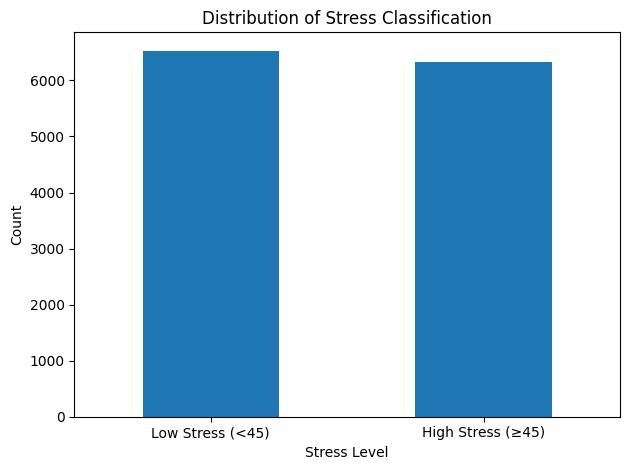

In [237]:
import matplotlib.pyplot as plt

y_classification.value_counts().plot(kind='bar')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.title('Distribution of Stress Classification')
plt.xticks([0, 1], [f'Low Stress (<{STRESS_THRESHOLD})', f'High Stress (≥{STRESS_THRESHOLD})'], rotation=0)
plt.tight_layout()
plt.show()

In [238]:
X_train, X_test, y_train, y_test = train_test_split(X, y_classification, test_size=0.2, random_state=42)

In [239]:
from lazypredict.Supervised import LazyClassifier


In [240]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric = None, predictions=True)

scores, predictions = clf.fit(X_train, X_test, y_train, y_test)
scores

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 5052, number of negative: 5238
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 10290, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.490962 -> initscore=-0.036156
[LightGBM] [Info] Start training from score -0.036156


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
ExtraTreesClassifier,0.93,0.93,0.93,0.93,0.31
BaggingClassifier,0.93,0.93,0.93,0.93,0.09
RandomForestClassifier,0.92,0.92,0.92,0.92,0.38
DecisionTreeClassifier,0.92,0.92,0.92,0.92,0.02
ExtraTreeClassifier,0.92,0.92,0.92,0.92,0.01
XGBClassifier,0.91,0.91,0.91,0.91,0.11
KNeighborsClassifier,0.90,0.90,0.90,0.90,0.03
LGBMClassifier,0.89,0.89,0.89,0.89,0.30
LabelPropagation,0.83,0.83,0.83,0.83,2.51


In [241]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [242]:
# Create confusion matrices for the first 5 models
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

top_5_models = scores.head(5).index.tolist()

for idx, model_name in enumerate(top_5_models):
    y_pred = predictions[model_name]
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(model_name, fontsize=10)
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [243]:
# Get the top 10 models from scores
top_10_models = scores.head(10).index.tolist()

# Create confusion matrices for each of the top 10 models
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, model_name in enumerate(top_10_models):
    # Get predictions for this model
    y_pred = predictions[model_name]
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(model_name, fontsize=10)
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [244]:
from sklearn.inspection import permutation_importance

N = 5  # Puoi cambiare questo valore come preferisci

# Prendi i primi N modelli dal ranking
top_N_models = scores.head(N).index.tolist()

fig, axes = plt.subplots(1, N, figsize=(5*N, 5), sharey=True)

for idx, model_name in enumerate(top_N_models):
    # Ottieni il modello addestrato da LazyClassifier
    model = clf.models[model_name]
    # Calcola la feature importance
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])  # Use absolute values for classification
    else:
        # fallback: permutation importance
        result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
        importances = result.importances_mean

    axes[idx].barh(FEATURES, importances)
    axes[idx].set_title(model_name)
    axes[idx].set_xlabel("Importance")

plt.tight_layout()
plt.show()

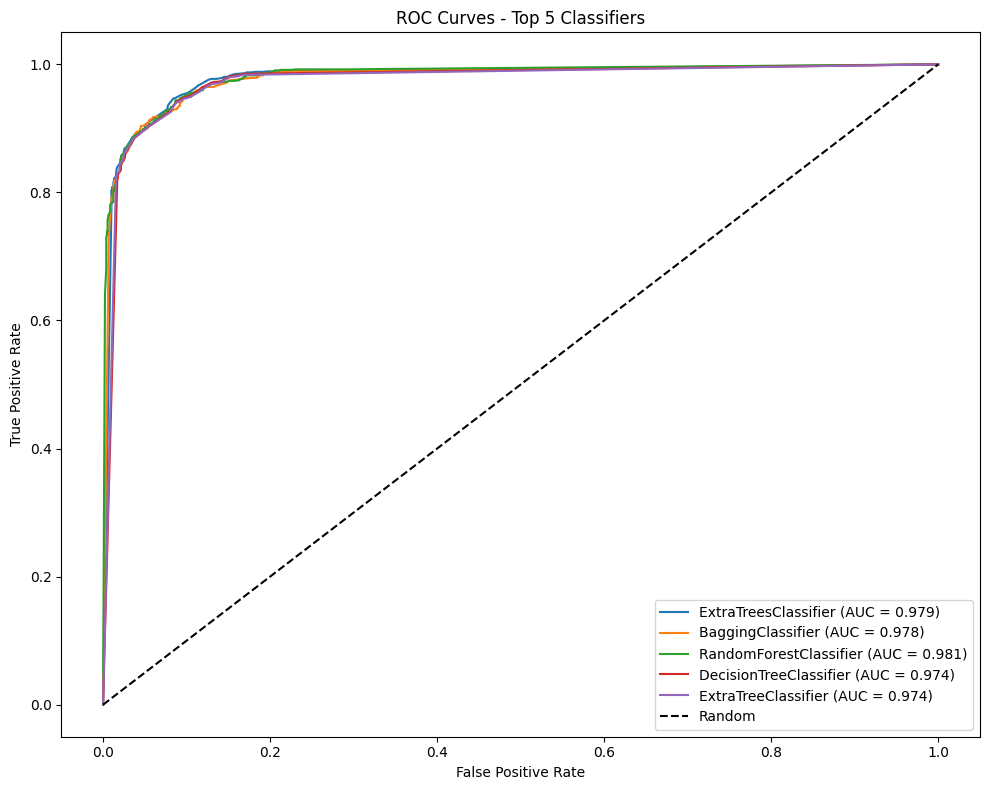

In [245]:
# 5. ROC curves for top N models
from sklearn.metrics import roc_curve, auc

N = 5
top_N_models = scores.head(N).index.tolist()

fig, ax = plt.subplots(figsize=(10, 8))

for model_name in top_N_models:
    model = clf.models[model_name]
    
    # Get probability predictions if available
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_pred_proba = model.decision_function(X_test)
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Top 5 Classifiers')
ax.legend()
plt.tight_layout()
plt.show()

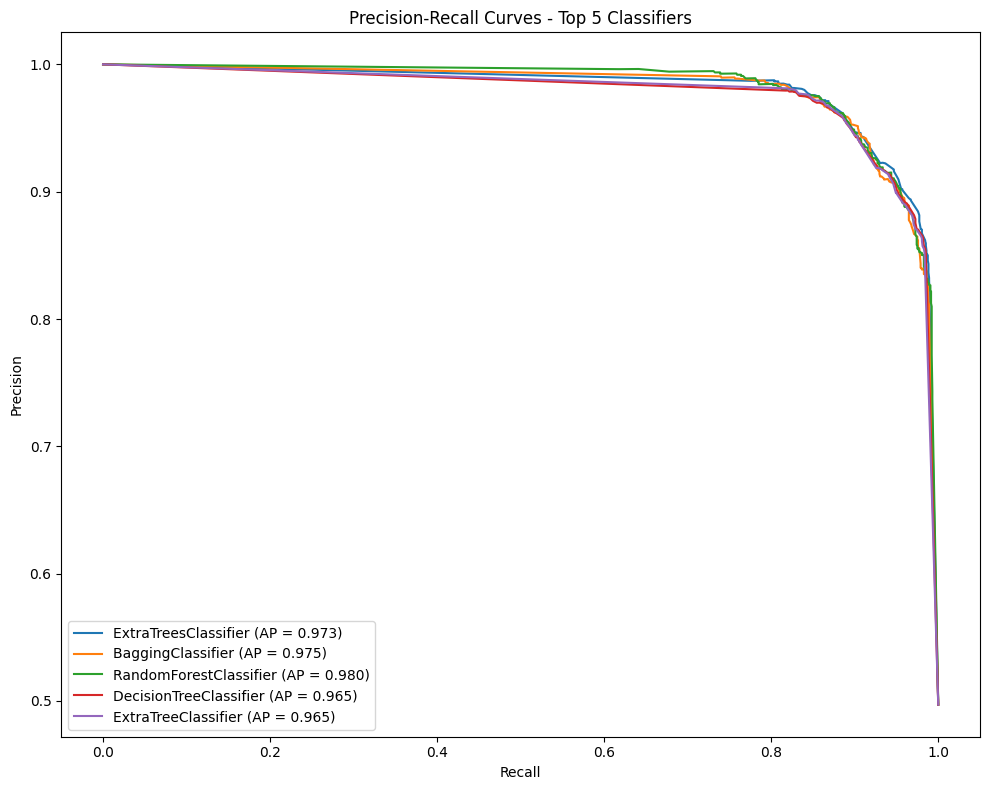

In [246]:
# 6. Precision-Recall curves
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 8))

for model_name in top_N_models:
    model = clf.models[model_name]
    
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_pred_proba = model.decision_function(X_test)
    else:
        continue
    
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    ax.plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves - Top 5 Classifiers')
ax.legend()
plt.tight_layout()
plt.show()

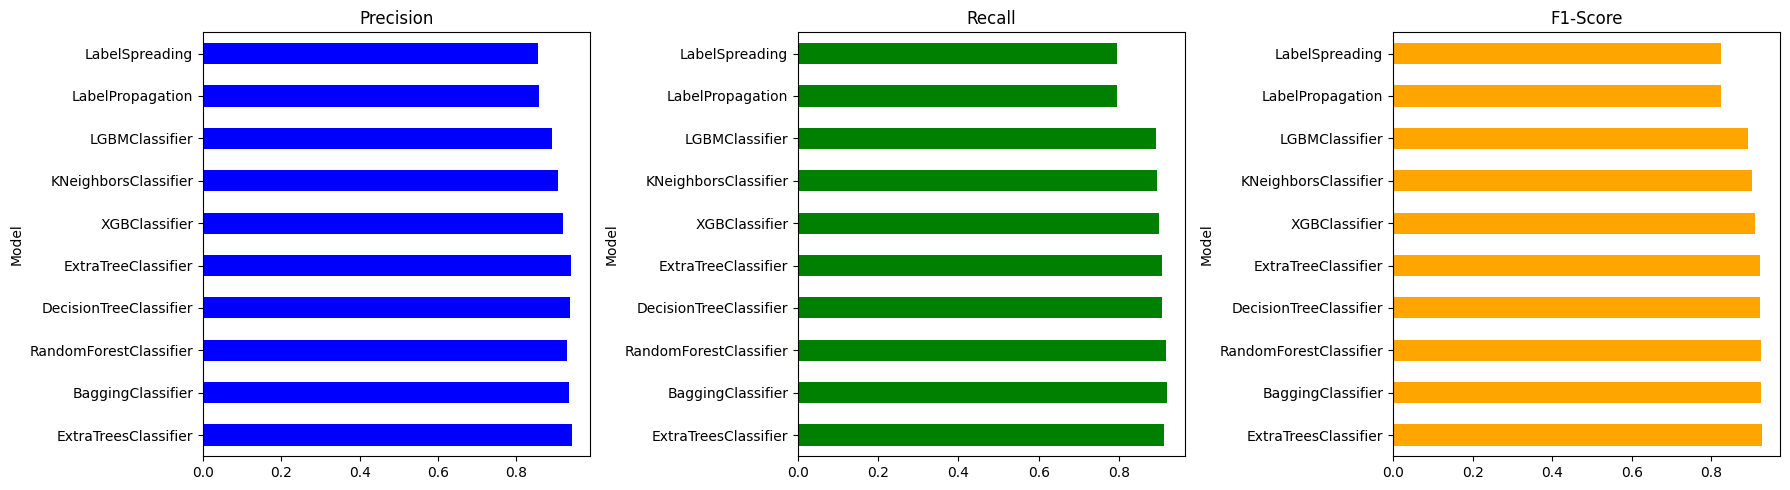

In [247]:
# 7. Classification metrics comparison
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_data = []
for model_name in scores.head(10).index:
    y_pred = predictions[model_name]
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    metrics_data.append({'Model': model_name, 'Precision': precision, 'Recall': recall, 'F1-Score': f1})

metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_df.plot(x='Model', y='Precision', kind='barh', ax=axes[0], legend=False, color='blue')
axes[0].set_title('Precision')
metrics_df.plot(x='Model', y='Recall', kind='barh', ax=axes[1], legend=False, color='green')
axes[1].set_title('Recall')
metrics_df.plot(x='Model', y='F1-Score', kind='barh', ax=axes[2], legend=False, color='orange')
axes[2].set_title('F1-Score')
plt.tight_layout()
plt.show()

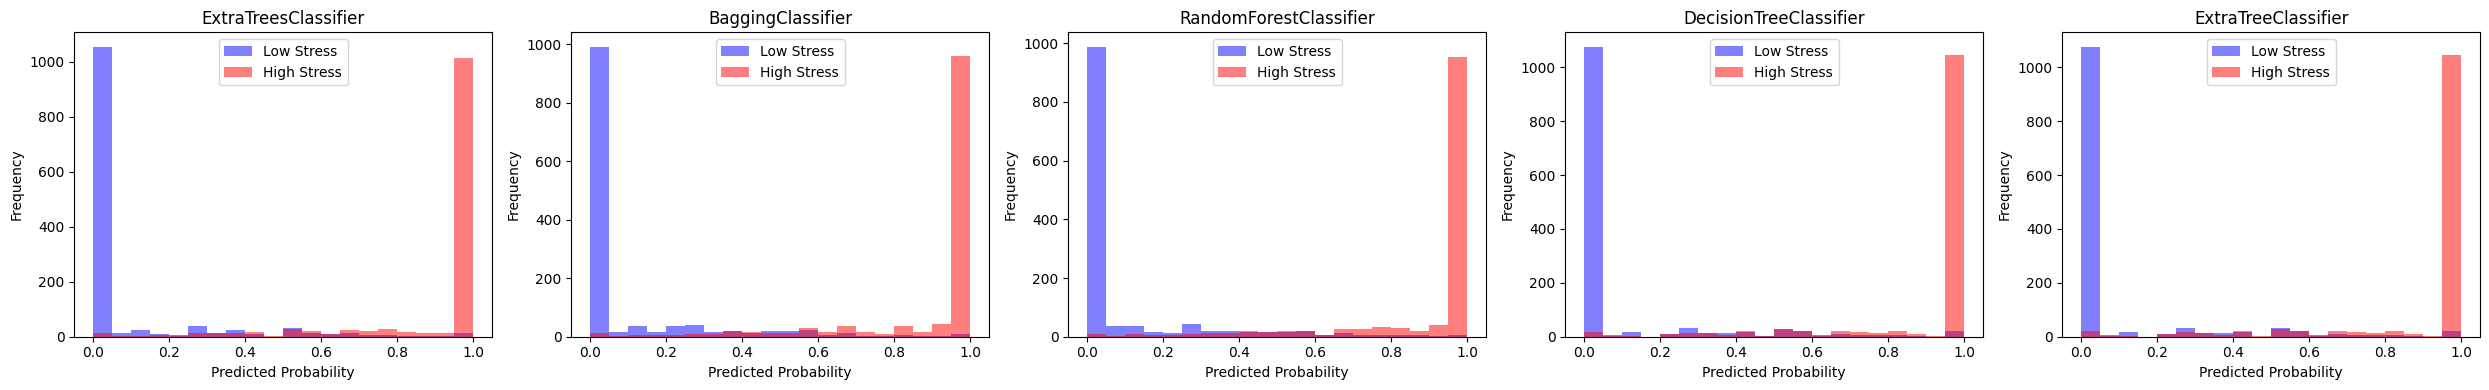

In [248]:
# 8. Prediction probability distribution
fig, axes = plt.subplots(1, N, figsize=(5*N, 4))

for idx, model_name in enumerate(top_N_models):
    model = clf.models[model_name]
    
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        axes[idx].hist(y_pred_proba[y_test == 0], bins=20, alpha=0.5, label='Low Stress', color='blue')
        axes[idx].hist(y_pred_proba[y_test == 1], bins=20, alpha=0.5, label='High Stress', color='red')
        axes[idx].set_xlabel('Predicted Probability')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{model_name}')
        axes[idx].legend()
        
plt.tight_layout()
plt.show()

Best models per family (Classification):
Tree-based: ExtraTreesClassifier (Acc = 0.9277, F1 = 0.9277)
SVM: SVC (Acc = 0.7995, F1 = 0.7985)
Linear: SGDClassifier (Acc = 0.7349, F1 = 0.7346)
Ensemble: BaggingClassifier (Acc = 0.9269, F1 = 0.9269)
Neighbors: KNeighborsClassifier (Acc = 0.9021, F1 = 0.9021)
Naive Bayes: BernoulliNB (Acc = 0.7085, F1 = 0.7069)
Other: LinearDiscriminantAnalysis (Acc = 0.7291, F1 = 0.7270)


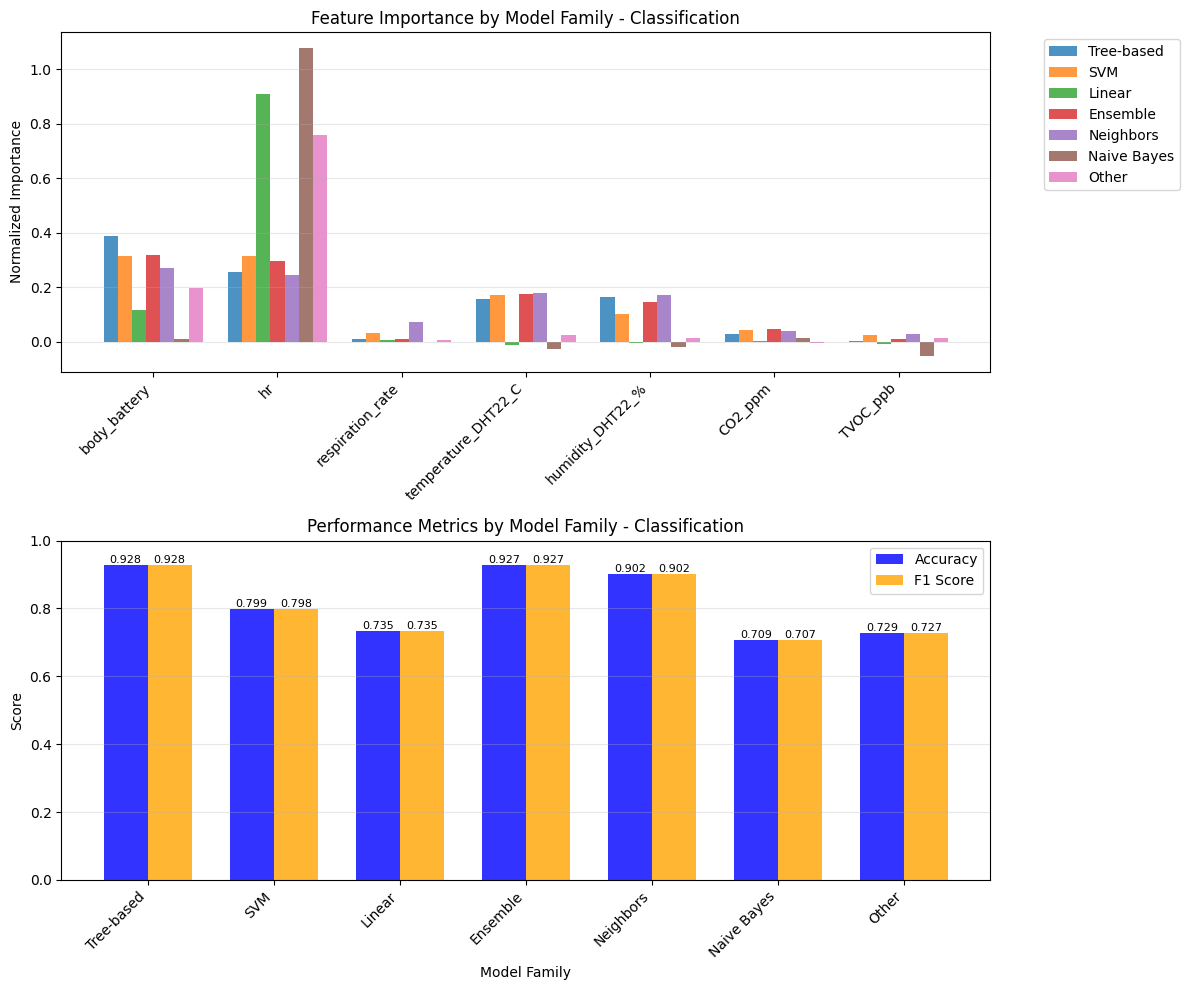

In [249]:
# 9. Feature Importance and Performance by Model Family - CLASSIFICATION
from sklearn.inspection import permutation_importance

# Define model families based on common model types
model_families_clf = {
    'Tree-based': ['ExtraTreesClassifier', 'RandomForestClassifier', 'GradientBoostingClassifier', 
                   'HistGradientBoostingClassifier', 'XGBClassifier', 'LGBMClassifier', 'DecisionTreeClassifier'],
    'SVM': ['SVC', 'NuSVC', 'LinearSVC'],
    'Linear': ['LogisticRegression', 'RidgeClassifier', 'SGDClassifier', 'Perceptron', 
               'PassiveAggressiveClassifier'],
    'Ensemble': ['AdaBoostClassifier', 'BaggingClassifier'],
    'Neighbors': ['KNeighborsClassifier', 'NearestCentroid'],
    'Naive Bayes': ['GaussianNB', 'BernoulliNB'],
    'Other': ['QuadraticDiscriminantAnalysis', 'LinearDiscriminantAnalysis']
}

# Get best model from each family
best_per_family_clf = {}
for family, model_types in model_families_clf.items():
    for model_name in scores.index:
        if any(model_type in model_name for model_type in model_types):
            if family not in best_per_family_clf:
                best_per_family_clf[family] = {
                    'name': model_name,
                    'accuracy': scores.loc[model_name, 'Accuracy'],
                    'f1': scores.loc[model_name, 'F1 Score']
                }
            break

# Remove empty families
best_per_family_clf = {k: v for k, v in best_per_family_clf.items() if v}

print("Best models per family (Classification):")
for family, info in best_per_family_clf.items():
    print(f"{family}: {info['name']} (Acc = {info['accuracy']:.4f}, F1 = {info['f1']:.4f})")

# Create subplots for feature importance and performance
n_families = len(best_per_family_clf)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Feature Importance for best model in each family
ax1 = axes[0]
x_pos = np.arange(len(FEATURES))
width = 0.8 / n_families

for idx, (family, info) in enumerate(best_per_family_clf.items()):
    model_name = info['name']
    model = clf.models[model_name]
    
    # Get feature importance
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    else:
        result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)
        importances = result.importances_mean
    
    # Normalize importances
    importances = importances / importances.sum()
    
    offset = (idx - n_families/2) * width + width/2
    ax1.bar(x_pos + offset, importances, width, label=f'{family}', alpha=0.8)

ax1.set_ylabel('Normalized Importance')
ax1.set_title('Feature Importance by Model Family - Classification')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(FEATURES, rotation=45, ha='right')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Performance Metrics (Accuracy and F1 Score)
ax2 = axes[1]
families = list(best_per_family_clf.keys())
accuracy_scores = [best_per_family_clf[f]['accuracy'] for f in families]
f1_scores = [best_per_family_clf[f]['f1'] for f in families]

x = np.arange(len(families))
width = 0.35

bars1 = ax2.bar(x - width/2, accuracy_scores, width, label='Accuracy', alpha=0.8, color='blue')
bars2 = ax2.bar(x + width/2, f1_scores, width, label='F1 Score', alpha=0.8, color='orange')

ax2.set_xlabel('Model Family')
ax2.set_ylabel('Score')
ax2.set_title('Performance Metrics by Model Family - Classification')
ax2.set_xticks(x)
ax2.set_xticklabels(families, rotation=45, ha='right')
ax2.legend()
ax2.set_ylim([0, 1.0])
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()